# Analisis Tingkat Kemiskinan Di Indonesia

## Latar Belakang



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Dataset_Kemiskinan.csv')


In [ ]:
df.head()

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
0,ACEH,Simeulue,8.180556,9.480000,7148,66.41,65.28,71.56,87.45,2.576389,71.15
1,ACEH,Aceh Singkil,20.360000,3.805556,8776,69.22,67.43,69.56,78.58,8.360000,62.85
2,ACEH,Aceh Selatan,13.180000,3.944444,8180,67.44,64.04,62.55,79.65,6.460000,60.85
3,ACEH,Aceh Tenggara,13.410000,4.215278,8030,69.44,68.22,62.71,86.71,6.430000,69.62
4,ACEH,Aceh Timur,14.450000,8.210000,8577,67.83,68.74,66.75,83.16,7.130000,59.48


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Provinsi     532 non-null    object 
 1   KabKota      532 non-null    object 
 2   Kemiskinan   532 non-null    float64
 3   RLS          532 non-null    float64
 4   Pengeluaran  532 non-null    int64  
 5   IPM          526 non-null    float64
 6   UHH          527 non-null    float64
 7   Sanitasi     531 non-null    float64
 8   AirMinum     529 non-null    float64
 9   TPT          532 non-null    float64
 10  TPAK         532 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 45.8+ KB


In [ ]:
df.shape


(532, 11)

In [ ]:
df.size

5852

In [ ]:
df.columns

Index(['Provinsi', 'KabKota', 'Kemiskinan', 'RLS', 'Pengeluaran', 'IPM', 'UHH',
       'Sanitasi', 'AirMinum', 'TPT', 'TPAK'],
      dtype='object')

4.	Pra Proses Data

a.	Bukti tahapan pemeriksaaan Missing Value

In [ ]:
df.isnull().sum()

,0
Provinsi,0
KabKota,0
Kemiskinan,0
RLS,0
Pengeluaran,0
IPM,6
UHH,5
Sanitasi,1
AirMinum,3
TPT,0


In [ ]:
#menghapus baris data yang memiliki nilai null
df.dropna(inplace=True)
#Mengecek data kembali
df.isnull().sum()

,0
Provinsi,0
KabKota,0
Kemiskinan,0
RLS,0
Pengeluaran,0
IPM,0
UHH,0
Sanitasi,0
AirMinum,0
TPT,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517 entries, 0 to 530
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Provinsi     517 non-null    object 
 1   KabKota      517 non-null    object 
 2   Kemiskinan   517 non-null    float64
 3   RLS          517 non-null    float64
 4   Pengeluaran  517 non-null    int64  
 5   IPM          517 non-null    float64
 6   UHH          517 non-null    float64
 7   Sanitasi     517 non-null    float64
 8   AirMinum     517 non-null    float64
 9   TPT          517 non-null    float64
 10  TPAK         517 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ KB



b.	Bukti tahapan pemeriksaaan Outliers


In [ ]:
df_copy = df.copy()
#cetak struktur data copy
print("Jumlah baris data copy: ", df_copy.shape[0])
print("Jumlah kolom data copy: ", df_copy.shape[1])

Jumlah baris data copy:  517
Jumlah kolom data copy:  11


In [ ]:
#menampilkan statistics
df_copy.describe()

,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,12.436242,6.649432,10703.951644,69.890754,69.675513,77.189846,85.359249,6.732062,69.518453
std,37.408846,2.726323,6814.711012,6.584107,3.515266,18.941066,15.295069,13.232694,6.428762
min,0.150000,0.268750,3976.000000,32.840000,55.430000,0.000000,0.000000,0.000000,56.390000
25%,4.638889,3.923611,8558.000000,66.650000,67.360000,70.200000,79.630000,2.305556,65.070000
50%,7.534722,7.310000,10175.000000,69.610000,70.010000,81.890000,89.710000,3.513889,68.980000
75%,13.410000,8.460000,11792.000000,73.090000,72.180000,89.940000,96.530000,5.440000,72.390000
max,834.000000,12.510000,117166.000000,87.180000,77.730000,99.970000,100.000000,99.305556,97.930000


**Outliers pada kolom kemiskinan**

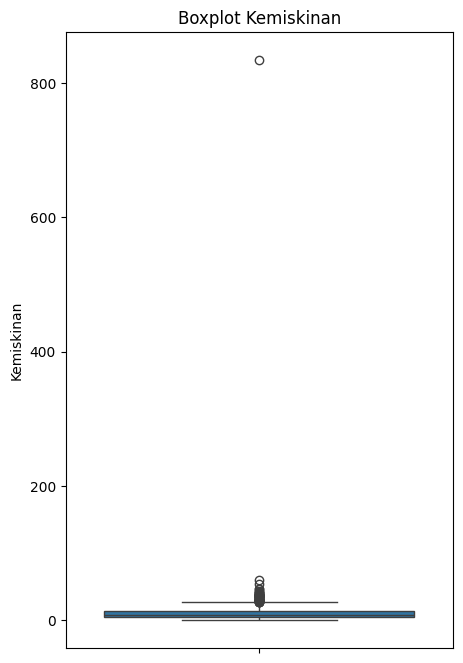

In [ ]:
#melihat outliers pada kolom kemiskinan dengan boxplot
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['Kemiskinan'])
plt.title('Boxplot Kemiskinan')
plt.show()

In [ ]:
#mencari outliers dengan persamaan
Q1 = df_copy.Kemiskinan.quantile(0.25)
Q3 = df_copy.Kemiskinan.quantile(0.75)
IQR = Q3 - Q1

#mencari batas atas/Q3
outlierQ3 = Q3 + (1.5 * IQR)

#membuang outlier (hanya mengambil data yang kurang dari batas atas)
df_copy = df_copy[(df_copy["Kemiskinan"] < outlierQ3)]

#menampilkan kembali staistics untuk kolom kemiskinan
df_copy["Kemiskinan"].describe()

,Kemiskinan
count,471.000000
mean,8.513412
std,5.506943
min,0.150000
25%,4.375000
50%,7.150000
75%,12.035000
max,26.530000


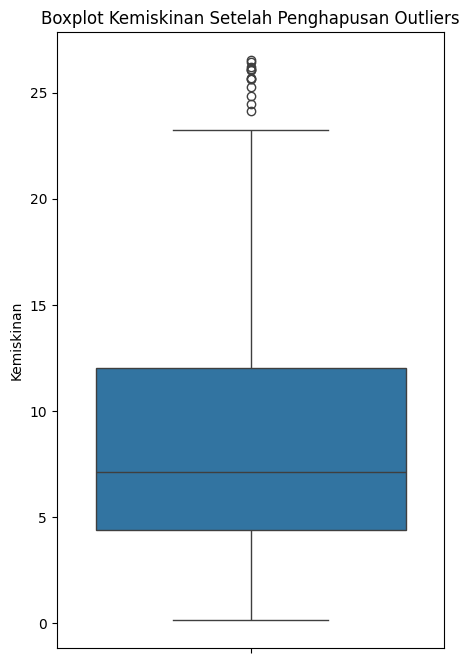

In [ ]:
#menampilkan kembali boxplot nya
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['Kemiskinan'])
plt.title('Boxplot Kemiskinan Setelah Penghapusan Outliers')
plt.show()

In [ ]:
#jumlah baris dan kolom setelah penghapusan outlier
print("Jumlah baris data copy: ", df_copy.shape[0])
print("Jumlah kolom data copy: ", df_copy.shape[1])

Jumlah baris data copy:  471
Jumlah kolom data copy:  11


**Outliers pada kolom TPT**

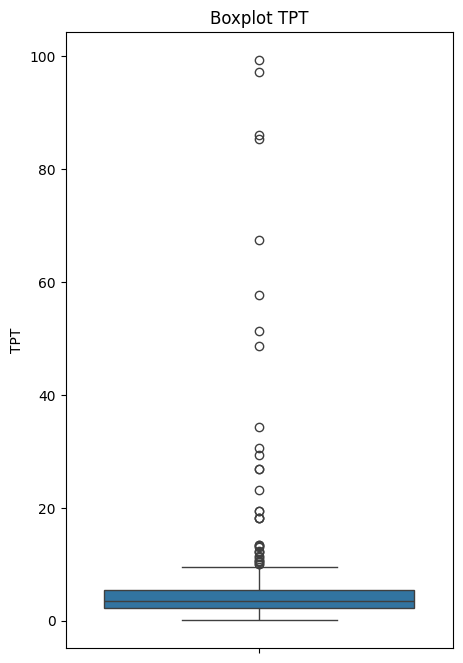

In [ ]:
#melihat outliers pada kolom kemiskinan dengan boxplot
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['TPT'])
plt.title('Boxplot TPT')
plt.show()

In [ ]:
#mencari outliers dengan persamaan
Q1 = df_copy.TPT.quantile(0.25)
Q3 = df_copy.TPT.quantile(0.75)
IQR = Q3 - Q1

#mencari batas atas/Q3
outlierQ3 = Q3 + (1.5 * IQR)

#membuang outlier (hanya mengambil data yang kurang dari batas atas)
df_copy = df_copy[(df_copy["TPT"] < outlierQ3)]

#menampilkan kembali staistics untuk kolom duration_sec
df_copy["TPT"].describe()

,TPT
count,437.000000
mean,3.878437
std,2.041150
min,0.100000
25%,2.300000
50%,3.430000
75%,5.060000
max,9.540000


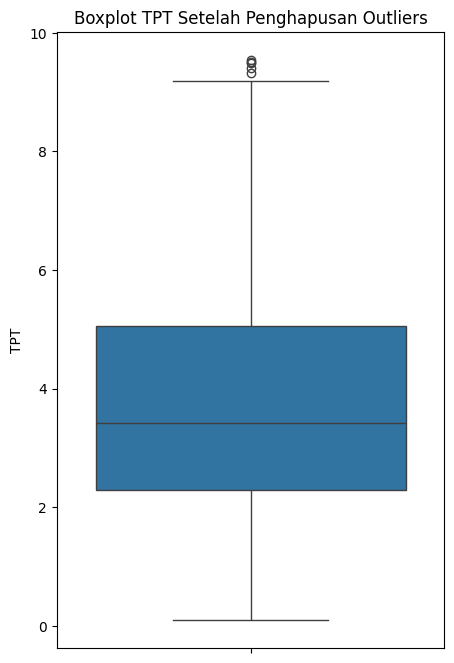

In [ ]:
#menampilkan kembali boxplot nya
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['TPT'])
plt.title('Boxplot TPT Setelah Penghapusan Outliers')
plt.show()

In [ ]:
#jumlah baris dan kolom setelah penghapusan outlier
print("Jumlah baris data copy: ", df_copy.shape[0])
print("Jumlah kolom data copy: ", df_copy.shape[1])

Jumlah baris data copy:  437
Jumlah kolom data copy:  11


**Outliers pada kolom Pengeluaran**

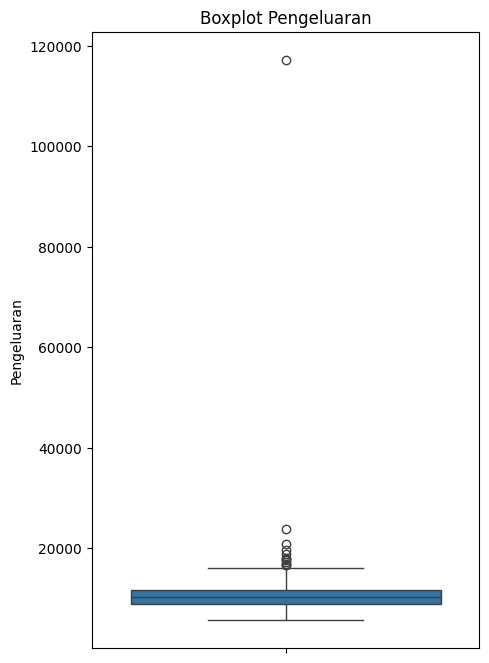

In [ ]:
#melihat outliers pada kolom kemiskinan dengan boxplot
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['Pengeluaran'])
plt.title('Boxplot Pengeluaran')
plt.show()

In [ ]:
#mencari outliers dengan persamaan
Q1 = df_copy.Pengeluaran.quantile(0.25)
Q3 = df_copy.Pengeluaran.quantile(0.75)
IQR = Q3 - Q1

#mencari batas atas/Q3
outlierQ3 = Q3 + (1.5 * IQR)

#membuang outlier (hanya mengambil data yang kurang dari batas atas)
df_copy = df_copy[(df_copy["Pengeluaran"] < outlierQ3)]

#menampilkan kembali staistics untuk kolom duration_sec
df_copy["Pengeluaran"].describe()

,Pengeluaran
count,425.000000
mean,10356.207059
std,2123.992649
min,5736.000000
25%,8850.000000
50%,10215.000000
75%,11658.000000
max,16095.000000


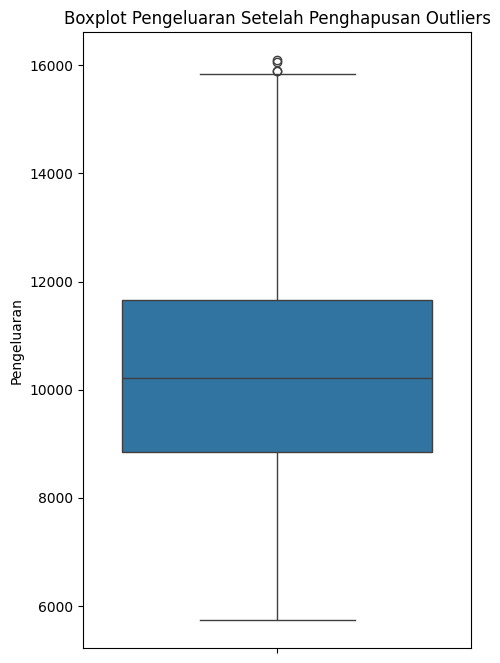

In [ ]:
#menampilkan kembali boxplot nya
plt.figure(figsize=(5,8))
sns.boxplot(df_copy['Pengeluaran'])
plt.title('Boxplot Pengeluaran Setelah Penghapusan Outliers')
plt.show()

In [ ]:
#jumlah baris dan kolom setelah penghapusan outlier
print("Jumlah baris data copy: ", df_copy.shape[0])
print("Jumlah kolom data copy: ", df_copy.shape[1])

Jumlah baris data copy:  425
Jumlah kolom data copy:  11


c.	Bukti tahapan pemeriksaaan Validasi Data (data duplikat)

In [ ]:
# Melihat apakah ada data yang terduplikasi
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 15


In [ ]:
# menampilkan kolom yang terduplikasi
df[df.duplicated()]

,Provinsi,KabKota,Kemiskinan,RLS,Pengeluaran,IPM,UHH,Sanitasi,AirMinum,TPT,TPAK
22,ACEH,Gayo Lues,8.361111,8.040000,8856,67.56,65.53,47.63,84.68,0.100000,78.99
23,ACEH,Aceh Tamiang,13.340000,3.965278,8367,69.48,69.63,87.45,83.12,26.875000,66.43
25,ACEH,Aceh Selatan,13.180000,3.944444,8180,67.44,64.04,62.55,79.65,6.460000,60.85
26,ACEH,Aceh Tenggara,13.410000,4.215278,8030,69.44,68.22,62.71,86.71,6.430000,69.62
60,SUMATERA UTARA,Kota Tebing Tinggi,10.030000,10.440000,12939,75.42,70.95,95.88,99.35,8.370000,67.19
61,SUMATERA UTARA,Kota Medan,8.340000,11.480000,14999,81.21,73.23,92.71,98.80,4.729167,62.16
82,SUMATERA BARAT,Pasaman Barat,7.510000,8.270000,9089,68.76,67.94,70.28,81.47,5.020000,66.93
83,SUMATERA BARAT,Kota Padang,2.319444,11.590000,14540,82.09,73.69,80.13,95.52,13.370000,63.78
196,JAWA BARAT,Kota Bekasi,2.180556,11.310000,15903,81.95,75.19,97.54,100.00,4.777778,64.76
197,JAWA BARAT,Kota Depok,2.580000,11.460000,15420,81.37,74.62,97.06,99.52,4.277778,62.62


In [ ]:
#mengahapus data duplikat
df_copy = df_copy.drop_duplicates()

In [ ]:
#jumlah baris dan kolom setelah penghapusan data duplikat
print("Jumlah baris data copy: ", df_copy.shape[0])
print("Jumlah kolom data copy: ", df_copy.shape[1])

Jumlah baris data copy:  413
Jumlah kolom data copy:  11


Korelasi Antar Variabel

a.	Eksplorasi Variabel Utama

count    413.000000
mean       8.771944
std        5.584942
min        0.606250
25%        4.597222
50%        7.236111
75%       12.330000
max       26.530000
Name: Kemiskinan, dtype: float64


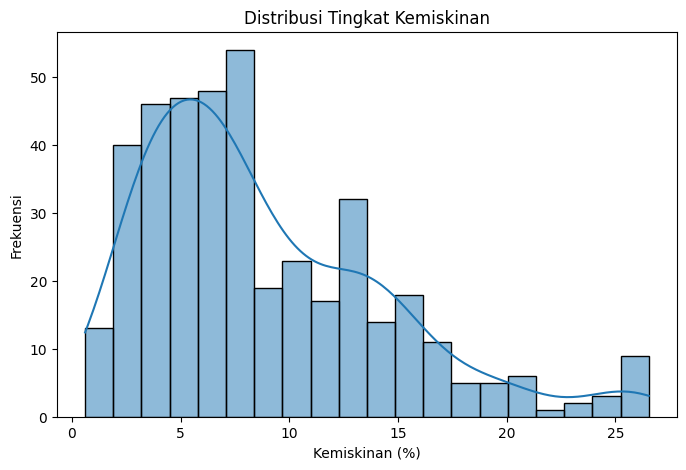

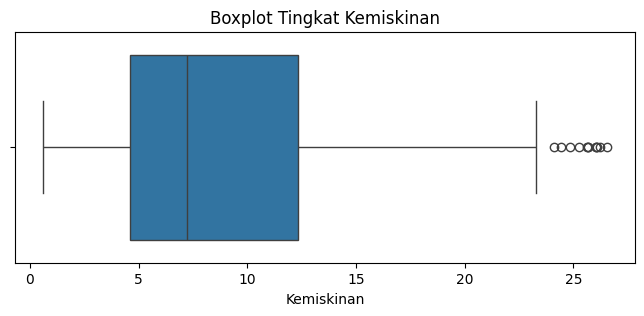

In [ ]:
# Statistik deskriptif
print(df_copy['Kemiskinan'].describe())

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df_copy['Kemiskinan'], bins=20, kde=True)
plt.title('Distribusi Tingkat Kemiskinan')
plt.xlabel('Kemiskinan (%)')
plt.ylabel('Frekuensi')
plt.show()

# Boxplot
plt.figure(figsize=(8,3))
sns.boxplot(x=df_copy['Kemiskinan'])
plt.title('Boxplot Tingkat Kemiskinan')
plt.show()



b.	Korelasi  Antar Variabel/fitur

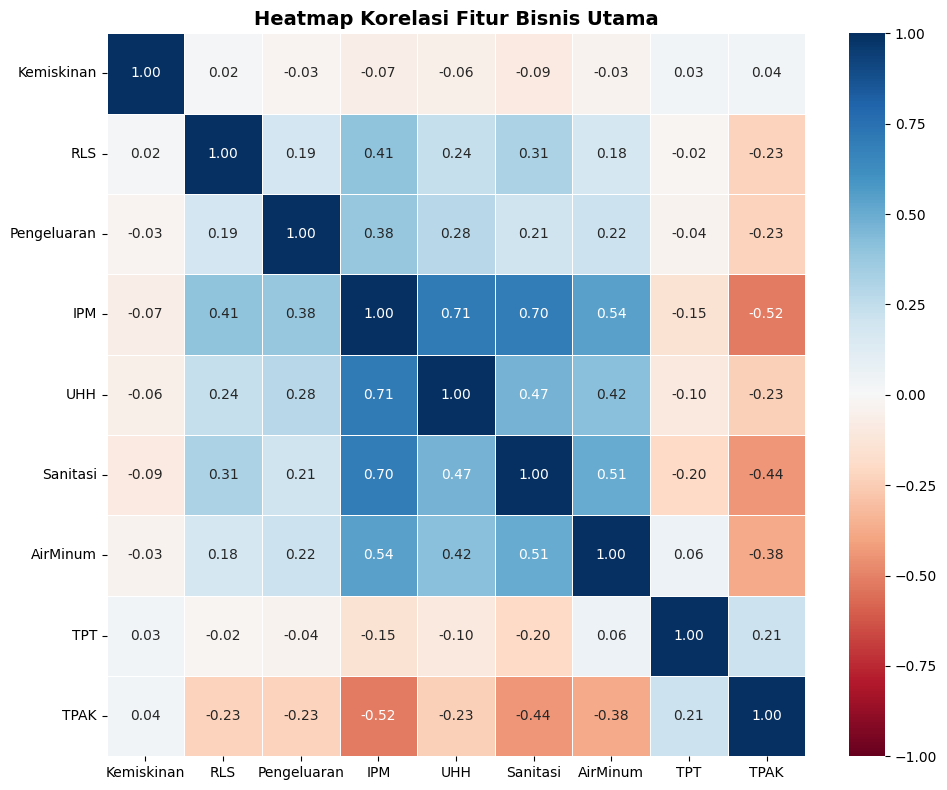

In [ ]:
# Memilih kolom spesifik yang mencerminkan dinamika operasional & bisnis
kolom_korelasi = ['Kemiskinan', 'RLS', 'Pengeluaran', 'IPM', 'UHH', 'Sanitasi', 'AirMinum', 'TPT', 'TPAK']

# Menghitung matriks korelasi Pearson
corr_matrix = df[kolom_korelasi].corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Bisnis Utama', fontsize=14, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretasi Matriks Korelasi

Matriks korelasi menunjukkan hubungan antar variabel dalam dataset kemiskinan.

**1. Indeks Pembangunan Manusia (IPM) dan Umur Harapan Hidup (UHH) (0.71)**

Variabel **IPM** memiliki hubungan yang sangat kuat dengan **UHH**. Selain itu, **sanitasi** juga memiliki hubungan positif dengan IPM.

**Insight:**
semakin tinggi SDM nya , tinggi juga harapan hidup SDM nya

---

**2. Kemiskinan dan Tingkat Pengangguran Terbuka (TPT) (0,03)**

Variabel **Kemiskinan** memiliki hubungan yang sangat lemah dengan **TPT**.

**Insight:**
Faktor yang memengaruhi kemiskinan penduduk belum tentu dari tingkat pengangguran terbuka.bisa jadi dari faktor lain

---

**3. Indeks Pembangunan Manusia(IPM) dan TINGKAT PARTISIPASI ANGKATAN KERJA (TPAK)** (-0,52)**

Terdapat hubungan negatif antara **IPM** dan **TPAK**. Artinya, semakin besar SDM nya, semakin kecil persentase partisipasi kerjanya.

**Insight:**


### Kesimpulan




In [ ]:
#konversi DataFrame ke excel
df_copy.to_excel('Dataset_Kemiskinan_cleaned.xlsx', index=False)